In [23]:
import random
import numpy as np
import torch

SEED = 2025

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch (CPU)
torch.manual_seed(SEED)

# PyTorch (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [24]:
import kagglehub

path = kagglehub.dataset_download(
    "hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images"
)

print(path)

Using Colab cache for faster access to the 'melanoma-skin-cancer-dataset-of-10000-images' dataset.
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images


In [25]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(dirs)
    break

/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images
['melanoma_cancer_dataset']


In [26]:
base = os.path.join(path, "melanoma_cancer_dataset")

train_path = os.path.join(base, "train")
test_path  = os.path.join(base, "test")

In [27]:
#Importing datasets and documenting the train, test, and validation set
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_train_dataset = datasets.ImageFolder(train_path, transform=transform)
test_dataset = datasets.ImageFolder(test_path, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator = torch.Generator().manual_seed(SEED))


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator = torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", full_train_dataset.classes)
print("Train Size:", len(train_dataset))
print("Validation Size:", len(val_dataset))
print("Test Size:", len(test_dataset))
print("Full Size:", len(full_train_dataset) + len(test_dataset))

Classes: ['benign', 'malignant']
Train Size: 7684
Validation Size: 1921
Test Size: 1000
Full Size: 10605


In [28]:
#Confirming the usage of cuda for GPU implementation
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

print(device)

cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [29]:
#Checking for class imbalance
from collections import Counter

malignant_count = Counter(full_train_dataset.targets)[1]
benign_count = Counter(full_train_dataset.targets)[0]

print("Malignant Class Count in Training Data:", malignant_count)
print("Benign Class Count in Training Data:", benign_count)


Malignant Class Count in Training Data: 4605
Benign Class Count in Training Data: 5000


In [30]:
#Implementing plot_training_curves() function used in previous homework for CS372
from matplotlib import pyplot as plt

def plot_training_curves(train_losses, val_accuracies):
    """Plot training loss and validation accuracy curves.

    Parameters
    ----------
    train_losses : list of float
        Training loss values for each epoch. Should have one value per epoch.
    val_accuracies : list of float
        Validation accuracy values for each epoch. Should have same length as
        train_losses. Accuracy values should be between 0 and 1 (or 0 and 100
        if using percentages).

    Returns
    -------
    None
        Displays matplotlib figure with two subplots showing training curves.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(val_accuracies)
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# CNN

In [31]:
#Defining CNN
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

class ResidualBlock(nn.Module):
    """Helper class that creates Residual Blocks for the CNN.

    Parameters
    ----------
    in_channels : int
        Number of input channels.
    out_channels : int
        Number of output channels.

    Returns
    -------
    Forwards a single Residual Block.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x += residual
        x = F.relu(x)
        return x

#224x224x3 to 55x55x96 to 27x27x96 to 13x13x256 to 13x13x384 to 13x13x256 to 6x6x256
#Flatten to 9216 to 4096 to 1000
class CNN(nn.Module):
    """Class for implementing the CNN.

    Uses
    ----------
    Several convolutional layers conv1, conv2, conv3, and conv4
    Batch Normalization
    Max Pooling
    Dropout Regularization with p = 0.5
    Fully-Connected Linear Layers fc1, fc2, and fc3
    ReLU Activation

    Returns
    -------
    Forwards CNN.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 96, kernel_size = 11, padding = 2, stride = 4)
        self.bn1 = nn.BatchNorm2d(96)
        self.pool = nn.MaxPool2d(kernel_size = 3, stride = 2)

        self.conv2 = nn.Conv2d(96, 256, kernel_size = 5, padding = 2)
        self.bn2 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size = 3, stride = 2)

        self.res1 = ResidualBlock(256, 256)

        self.conv3 = nn.Conv2d(256, 384, kernel_size = 3, padding = 1)
        self.bn3 = nn.BatchNorm2d(384)

        self.conv4 = nn.Conv2d(384, 256, kernel_size = 3, padding = 1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size = 3, stride = 2)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 4096)
        self.fc2 = nn.Linear(4096, 1000)
        self.fc3 = nn.Linear(1000, 2)
        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.pool(x)
        x = self.res1(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x


Epoch 01/20 | Loss: 0.603 | Train acc: 80.3% | Val acc: 85.6% | Time: 16.5s
Epoch 02/20 | Loss: 0.341 | Train acc: 85.2% | Val acc: 87.9% | Time: 16.6s
Epoch 03/20 | Loss: 0.298 | Train acc: 87.3% | Val acc: 87.7% | Time: 16.5s
Epoch 04/20 | Loss: 0.278 | Train acc: 88.1% | Val acc: 88.0% | Time: 16.4s
Epoch 05/20 | Loss: 0.278 | Train acc: 88.9% | Val acc: 89.3% | Time: 16.6s
Epoch 06/20 | Loss: 0.264 | Train acc: 88.9% | Val acc: 89.2% | Time: 16.4s
Epoch 07/20 | Loss: 0.245 | Train acc: 90.2% | Val acc: 88.3% | Time: 16.3s
Early stopping triggered.
Training complete.


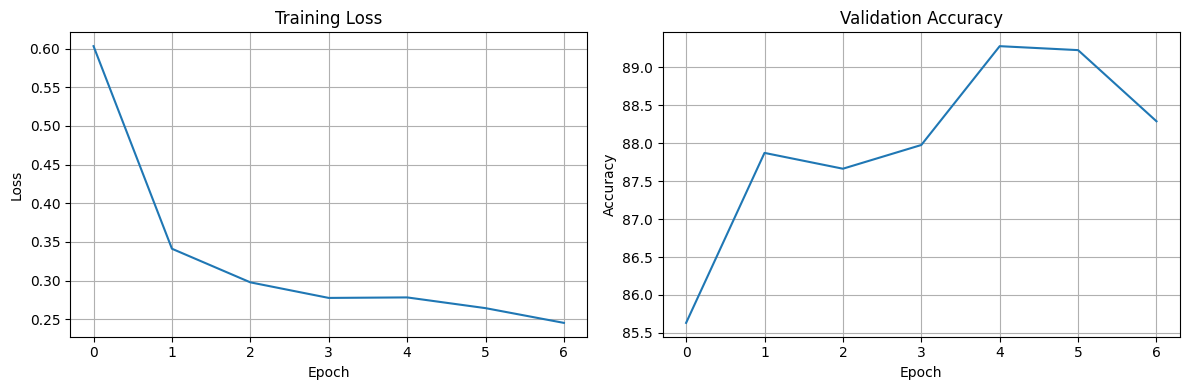

In [32]:
#Training CNN
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
torch.manual_seed(SEED)

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

torch.save(model.state_dict(), "cnn.pth")

# ResNet-18-Inspired Implementation

In [33]:
#Defining ResNet18
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

class ResNet18(nn.Module):
    """Class for implementing the ResNet18.

    Uses
    ----------
    Backbone model resnet18
    Sequential stem with conv1, bn1, and relu
    Sequential layers layer1, layer2, layer3, and layer4
    Average Pooling
    Max Pooling
    Dropout Regularization with p = 0.5
    Linear Layers
    Linear Layers classifier
    ReLU Activation

    Returns
    -------
    Forwards ResNet18.
    """
    def __init__(self):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10000),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(10000, 2)
            )

    def forward(self, x):
      x = self.stem(x)
      x = self.layer1(x)
      x = self.layer2(x)
      x = self.layer3(x)
      x = self.layer4(x)
      x = self.gap(x)
      x = self.classifier(x)
      return x

Epoch 01/20 | Loss: 0.422 | Train acc: 85.0% | Val acc: 88.8% | Time: 23.9s
Epoch 02/20 | Loss: 0.317 | Train acc: 88.5% | Val acc: 68.6% | Time: 23.7s
Epoch 03/20 | Loss: 0.351 | Train acc: 86.0% | Val acc: 89.5% | Time: 23.4s
Epoch 04/20 | Loss: 0.298 | Train acc: 89.1% | Val acc: 88.9% | Time: 23.4s
Epoch 05/20 | Loss: 0.266 | Train acc: 89.8% | Val acc: 88.4% | Time: 23.6s
Early stopping triggered.
Training complete.


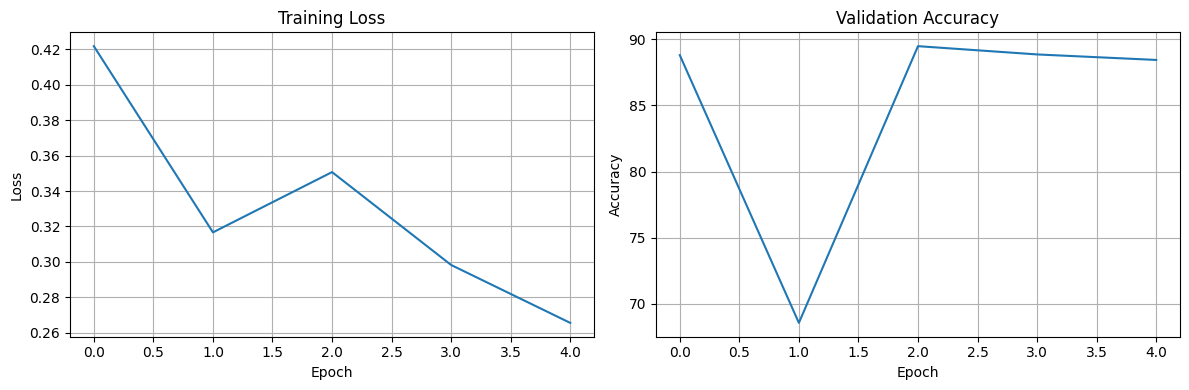

In [34]:
#Training ResNet18
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = ResNet18().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

torch.save(model.state_dict(), "res18.pth")

# EfficientNet-B0-Inspired Implementation

In [35]:
#Defining EfficientNet-B0
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

class Swish(nn.Module):
  """Class for implementing Swish


    Returns
    -------
    Swish Activation.
  """
  def forward(self, x):
    return x * torch.sigmoid(x)

class SEBlock(nn.Module):
  """Class for implementing Squeeve and Excitation Block

    Uses
    ----------
    in_channels : int
        Number of input channels.
    reduction_ratio : int
        Reduction ratio for squeeze and excitation.
    Average Pooling
    Linear Layers
    Sigmoid Activation

    Returns
    -------
    Applies Squeeze-and-Excitation.
  """
  def __init__(self, in_channels, reduction_ratio=4):
    super().__init__()
    self.avg_pool = nn.AdaptiveAvgPool2d(1)
    self.fc = nn.Sequential(
        nn.Linear(in_channels, in_channels // reduction_ratio),
        Swish(),
        nn.Linear(in_channels // reduction_ratio, in_channels),
        nn.Sigmoid()
    )

  def forward(self, x):
    b, c, _, _ = x.size()
    y = self.avg_pool(x).view(b, c)
    y = self.fc(y).view(b, c, 1, 1)
    return x * y


class MBConv(nn.Module):
  """Class for implementing Mobile Inverted Bottleneck Convolution

    Uses
    ----------
    in_channels : int
        Number of input channels.
    out_channels : int
        Number of output channels.
    kernel_size : int
        Kernel size for convolution.
    stride : int
        Stride for convolution.
    expand_ratio : int
        Expansion ratio for inverted bottleneck.
    Average Pooling
    Linear Layers
    Sigmoid Activation
    Batch Normalization
    Swish Activation

    Returns
    -------
    Implements Mobile-Inverted Bottleneck that downsample spatial dimensions
    and increase depth of feature maps.
  """
  def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, expand_ratio=1):
    super().__init__()
    self.use_residual = in_channels == out_channels and stride == 1
    hidden_dim = in_channels * expand_ratio
    layers = []
    if expand_ratio != 1:
      layers.append(nn.Conv2d(in_channels, hidden_dim, 1, 1, 0, bias=False))
      layers.append(nn.BatchNorm2d(hidden_dim))
      layers.append(Swish())

    layers.append(nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride, kernel_size//2, groups=hidden_dim, bias=False))
    layers.append(nn.BatchNorm2d(hidden_dim))
    layers.append(Swish())
    layers.append(SEBlock(hidden_dim))
    layers.append(nn.Conv2d(hidden_dim, out_channels, 1, 1, 0, bias=False))
    layers.append(nn.BatchNorm2d(out_channels))
    self.conv = nn.Sequential(*layers)

  def forward(self, x):
    out = self.conv(x)
    if self.use_residual:
      out = x + out
    return out


class My_EfficientNet(nn.Module):
  """Class for implementing EfficientNet-B0.

    Uses
    ----------
    Sequential Stem
    Sequential Layers
    Adaptive Average Pooling
    Flatten
    Dropout Regularization with p = 0.2
    Linear Layers
    Softmax Activation

    Returns
    -------
    Implements Mobile-Inverted Bottleneck that downsample spatial dimensions
    and increase depth of feature maps.
  """
  def __init__(self, num_classes=2):
    super().__init__()
    self.stem = nn.Sequential(
        nn.Conv2d(3, 32, 3, 2, 1, bias=False),
        nn.BatchNorm2d(32),
        Swish()
    )
    self.blocks = nn.Sequential(
        MBConv(32, 16, 3, 1, 1),
        MBConv(16, 24, 3, 2, 6),
        MBConv(24, 24, 3, 1, 6),
        MBConv(24, 40, 5, 2, 6),
        MBConv(40, 40, 5, 1, 6),
        MBConv(40, 80, 3, 2, 6),
        MBConv(80, 80, 3, 1, 6),
        MBConv(80, 80, 3, 1, 6),
        MBConv(80, 112, 5, 1, 6),
        MBConv(112, 112, 5, 1, 6),
        MBConv(112, 192, 5, 1, 6),
        MBConv(192, 192, 5, 1, 6),
        MBConv(192, 192, 5, 1, 6),
        MBConv(192, 192, 5, 1, 6),
        MBConv(192, 320, 3, 1, 6),
    )
    self.chead = nn.Sequential(
        nn.Conv2d(320, 1280, 1, 1, 0, bias=False),
        nn.BatchNorm2d(1280),
        Swish()
    )

    self.head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(0.2),
        nn.Linear(1280, num_classes)
    )

    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    x = self.stem(x)
    x = self.blocks(x)
    x = self.chead(x)
    x = self.head(x)
    x = self.softmax(x)
    return x


Epoch 01/20 | Loss: 0.462 | Train acc: 84.2% | Val acc: 88.6% | Time: 21.0s
Epoch 02/20 | Loss: 0.432 | Train acc: 87.7% | Val acc: 90.6% | Time: 21.1s
Epoch 03/20 | Loss: 0.414 | Train acc: 89.6% | Val acc: 91.3% | Time: 21.3s
Epoch 04/20 | Loss: 0.416 | Train acc: 89.5% | Val acc: 91.7% | Time: 21.1s
Epoch 05/20 | Loss: 0.404 | Train acc: 90.7% | Val acc: 92.3% | Time: 21.3s
Epoch 06/20 | Loss: 0.397 | Train acc: 91.4% | Val acc: 91.3% | Time: 21.1s
Epoch 07/20 | Loss: 0.399 | Train acc: 91.0% | Val acc: 92.7% | Time: 21.1s
Epoch 08/20 | Loss: 0.391 | Train acc: 91.9% | Val acc: 93.0% | Time: 21.6s
Epoch 09/20 | Loss: 0.394 | Train acc: 91.6% | Val acc: 91.5% | Time: 21.4s
Epoch 10/20 | Loss: 0.384 | Train acc: 92.8% | Val acc: 92.0% | Time: 20.9s
Epoch 11/20 | Loss: 0.378 | Train acc: 93.5% | Val acc: 91.5% | Time: 21.2s
Epoch 12/20 | Loss: 0.378 | Train acc: 93.3% | Val acc: 93.4% | Time: 21.4s
Epoch 13/20 | Loss: 0.369 | Train acc: 94.3% | Val acc: 93.1% | Time: 21.3s
Epoch 14/20 

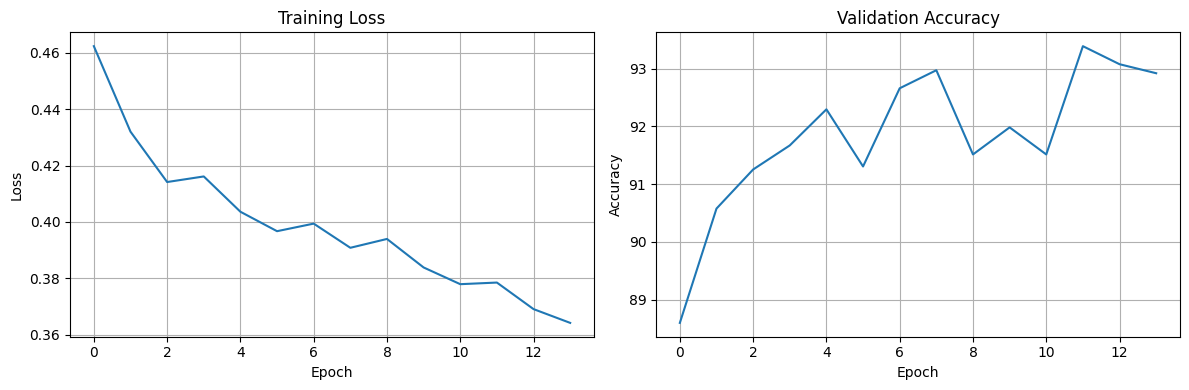

In [36]:
#Training EfficientNet-B0
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = My_EfficientNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

torch.save(model.state_dict(), "efficient-b0.pth")

# ViT-16

In [37]:
#Defining ViT
class VisionTransformer(nn.Module):
    """Class for implementing pre-trained ViT-b16.

    Uses
    ----------
    Backbone model vit_b_16
    Replaces head layers for binary classes (benign and malignant)

    Returns
    -------
    ViT Model for binary classes.
    """
    def __init__(self):
        super().__init__()
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        in_features = self.vit.heads.head.in_features
        self.vit.heads = nn.Linear(in_features, 2)


    def forward(self, x):
        return self.vit(x)


Epoch 01/20 | Loss: 0.492 | Train acc: 76.5% | Val acc: 73.9% | Time: 36.2s
Epoch 02/20 | Loss: 0.508 | Train acc: 74.5% | Val acc: 80.8% | Time: 36.0s
Epoch 03/20 | Loss: 0.403 | Train acc: 81.6% | Val acc: 82.7% | Time: 36.2s
Epoch 04/20 | Loss: 0.370 | Train acc: 83.6% | Val acc: 83.6% | Time: 36.2s
Epoch 05/20 | Loss: 0.352 | Train acc: 84.0% | Val acc: 84.7% | Time: 35.8s
Epoch 06/20 | Loss: 0.343 | Train acc: 84.9% | Val acc: 84.5% | Time: 35.9s
Epoch 07/20 | Loss: 0.326 | Train acc: 85.6% | Val acc: 86.0% | Time: 36.1s
Epoch 08/20 | Loss: 0.316 | Train acc: 86.4% | Val acc: 87.5% | Time: 36.1s
Epoch 09/20 | Loss: 0.299 | Train acc: 87.6% | Val acc: 87.7% | Time: 35.8s
Epoch 10/20 | Loss: 0.283 | Train acc: 88.2% | Val acc: 88.4% | Time: 35.9s
Epoch 11/20 | Loss: 0.277 | Train acc: 88.3% | Val acc: 87.9% | Time: 36.0s
Epoch 12/20 | Loss: 0.267 | Train acc: 88.9% | Val acc: 89.3% | Time: 35.6s
Epoch 13/20 | Loss: 0.251 | Train acc: 89.4% | Val acc: 89.4% | Time: 36.1s
Epoch 14/20 

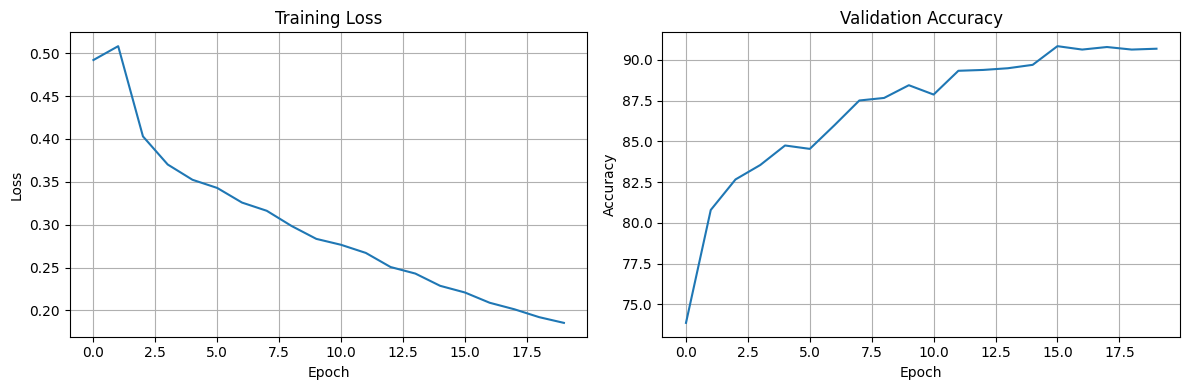

In [38]:
#Training ViT
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = VisionTransformer().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

torch.save(model.state_dict(), "vit.pth")

# Trying AdamW as Optimizer for EfficientNet-B0

Epoch 01/20 | Loss: 0.478 | Train acc: 82.5% | Val acc: 88.5% | Time: 21.2s
Epoch 02/20 | Loss: 0.433 | Train acc: 87.6% | Val acc: 90.9% | Time: 20.7s
Epoch 03/20 | Loss: 0.423 | Train acc: 88.7% | Val acc: 88.9% | Time: 20.6s
Epoch 04/20 | Loss: 0.421 | Train acc: 89.0% | Val acc: 92.3% | Time: 20.5s
Epoch 05/20 | Loss: 0.410 | Train acc: 90.1% | Val acc: 93.2% | Time: 20.5s
Epoch 06/20 | Loss: 0.410 | Train acc: 90.1% | Val acc: 89.1% | Time: 20.8s
Epoch 07/20 | Loss: 0.404 | Train acc: 90.8% | Val acc: 92.1% | Time: 21.0s
Epoch 08/20 | Loss: 0.396 | Train acc: 91.4% | Val acc: 92.8% | Time: 20.5s
Epoch 09/20 | Loss: 0.392 | Train acc: 92.2% | Val acc: 92.2% | Time: 20.6s
Epoch 10/20 | Loss: 0.392 | Train acc: 92.0% | Val acc: 93.4% | Time: 20.8s
Epoch 11/20 | Loss: 0.385 | Train acc: 92.6% | Val acc: 93.3% | Time: 20.6s
Epoch 12/20 | Loss: 0.381 | Train acc: 93.0% | Val acc: 93.6% | Time: 21.0s
Epoch 13/20 | Loss: 0.375 | Train acc: 93.8% | Val acc: 93.1% | Time: 21.2s
Epoch 14/20 

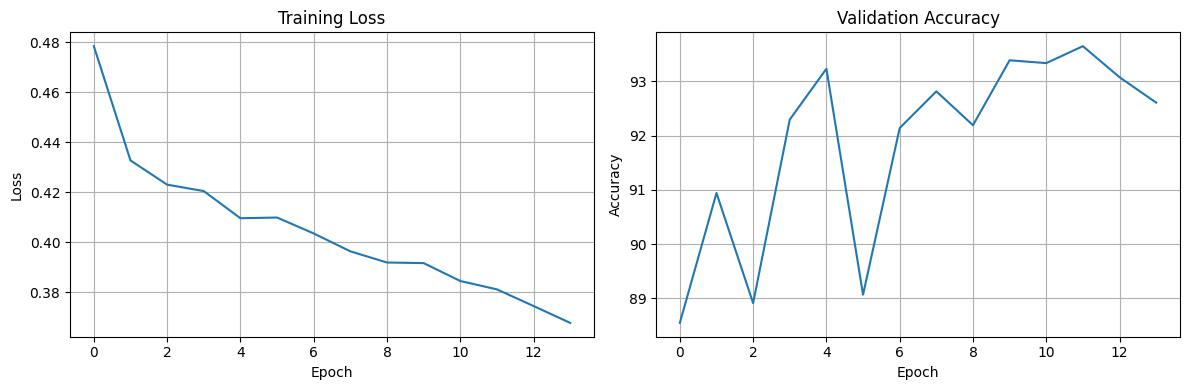

In [39]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = My_EfficientNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

# Trying SGD as Optimizer for EfficientNet-B0

Epoch 01/20 | Loss: 0.560 | Train acc: 74.8% | Val acc: 84.9% | Time: 21.0s
Epoch 02/20 | Loss: 0.453 | Train acc: 86.1% | Val acc: 88.6% | Time: 21.0s
Epoch 03/20 | Loss: 0.433 | Train acc: 87.7% | Val acc: 90.2% | Time: 21.2s
Epoch 04/20 | Loss: 0.423 | Train acc: 89.1% | Val acc: 89.1% | Time: 20.9s
Epoch 05/20 | Loss: 0.416 | Train acc: 89.3% | Val acc: 91.1% | Time: 21.5s
Epoch 06/20 | Loss: 0.408 | Train acc: 90.4% | Val acc: 91.4% | Time: 21.0s
Epoch 07/20 | Loss: 0.408 | Train acc: 90.3% | Val acc: 91.5% | Time: 21.3s
Epoch 08/20 | Loss: 0.400 | Train acc: 91.1% | Val acc: 91.4% | Time: 21.1s
Epoch 09/20 | Loss: 0.399 | Train acc: 91.3% | Val acc: 92.1% | Time: 21.2s
Epoch 10/20 | Loss: 0.394 | Train acc: 91.8% | Val acc: 92.2% | Time: 21.1s
Epoch 11/20 | Loss: 0.387 | Train acc: 92.6% | Val acc: 92.4% | Time: 21.1s
Epoch 12/20 | Loss: 0.386 | Train acc: 92.4% | Val acc: 93.0% | Time: 21.0s
Epoch 13/20 | Loss: 0.385 | Train acc: 92.7% | Val acc: 91.9% | Time: 21.5s
Epoch 14/20 

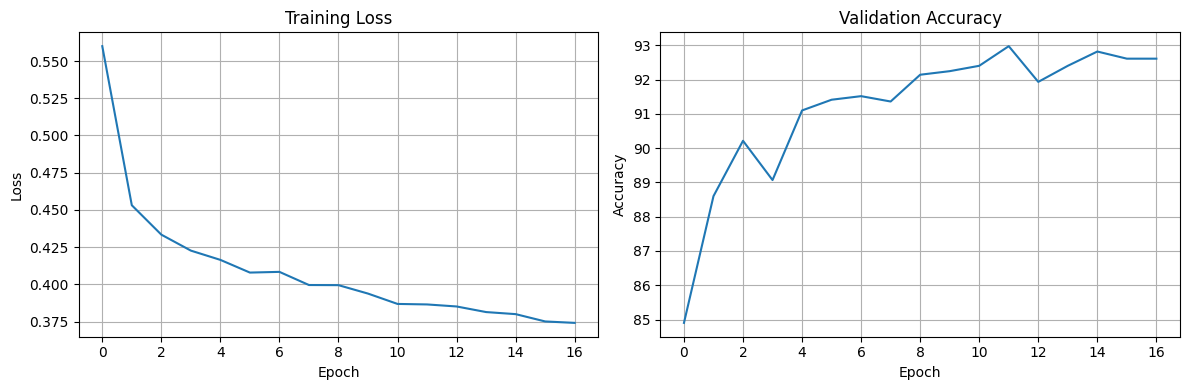

In [40]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(SEED)
model = My_EfficientNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

patience = 2
max_num_epochs = 20
epochs_counter = 0

training_loss = []
validation_accuracy = []
start_time = time.time()

def train(model):
    epochs_counter = 0
    for epoch in range(max_num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        mean_loss = train_loss / len(train_loader)
        training_loss.append(mean_loss)

        scheduler.step()
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100.* val_correct / val_total
        validation_accuracy.append(val_acc)


        print(f"Epoch {epoch+1:02d}/{max_num_epochs} | "
              f"Loss: {mean_loss:.3f} | "
              f"Train acc: {100.*correct/total:.1f}% | "
              f"Val acc: {val_acc:.1f}% | "
              f"Time: {time.time()-epoch_start_time:.1f}s")

        if len(validation_accuracy) > 1:
          if validation_accuracy[-1] <= validation_accuracy[-2]:
              epochs_counter += 1
              if epochs_counter == patience:
                  print("Early stopping triggered.")
                  break
          else:
              epochs_counter = 0

    print("Training complete.")

train(model)
plot_training_curves(training_loss, validation_accuracy)

# Sensitivity, Specificity Analysis on CNN, ResNet-18, EfficientNet-B0, and ViT

In [41]:
cnn = CNN().to(device)
cnn.load_state_dict(torch.load("cnn.pth", map_location=device))

res18 = ResNet18().to(device)
res18.load_state_dict(torch.load("res18.pth", map_location=device))

efficientnet = My_EfficientNet().to(device)
efficientnet.load_state_dict(torch.load("efficient-b0.pth", map_location=device))

vit = VisionTransformer().to(device)
vit.load_state_dict(torch.load("vit.pth", map_location=device))

<All keys matched successfully>

CNN → Test Accuracy: 89.40% | Correct: 894 | Incorrect: 106


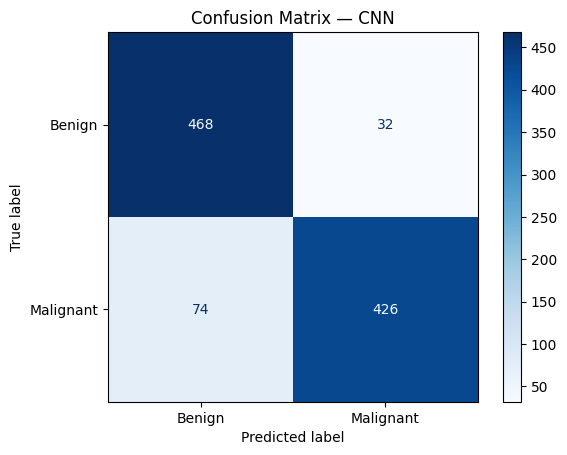

CNN: 74 false negatives found


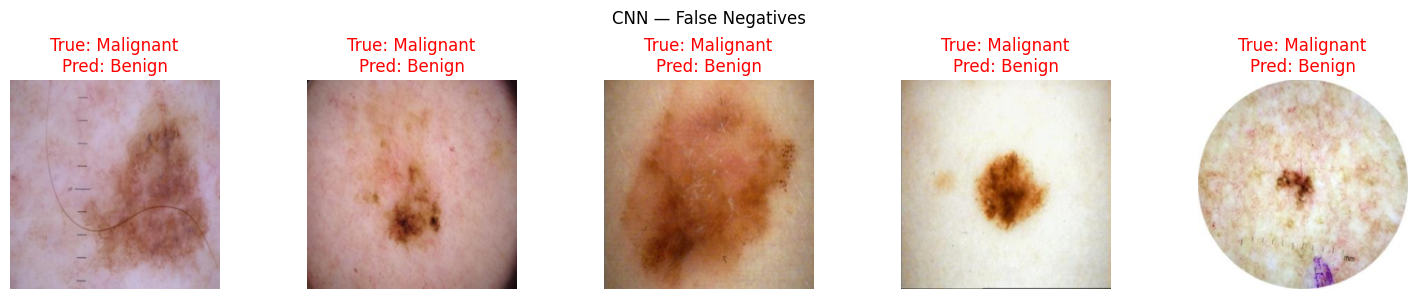

CNN: 32 false positives found


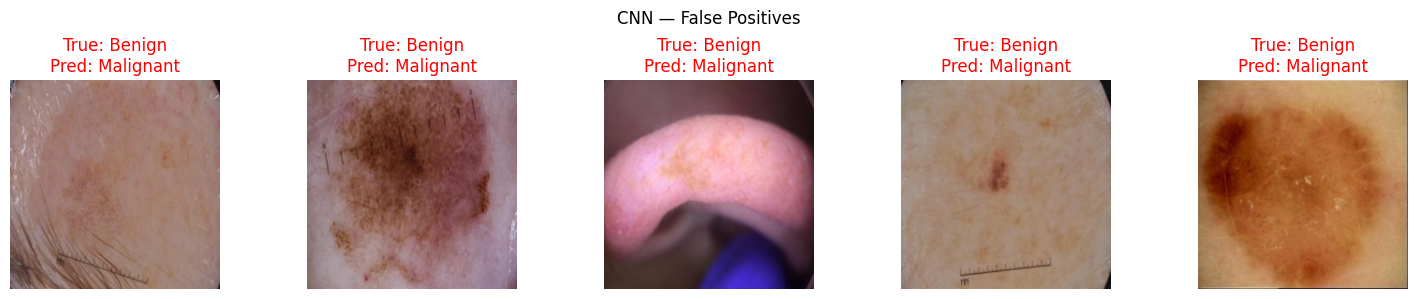

ResNet18 → Test Accuracy: 87.90% | Correct: 879 | Incorrect: 121


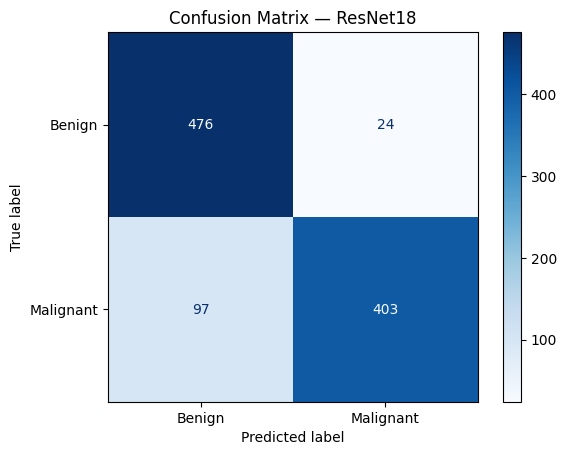

ResNet18: 97 false negatives found


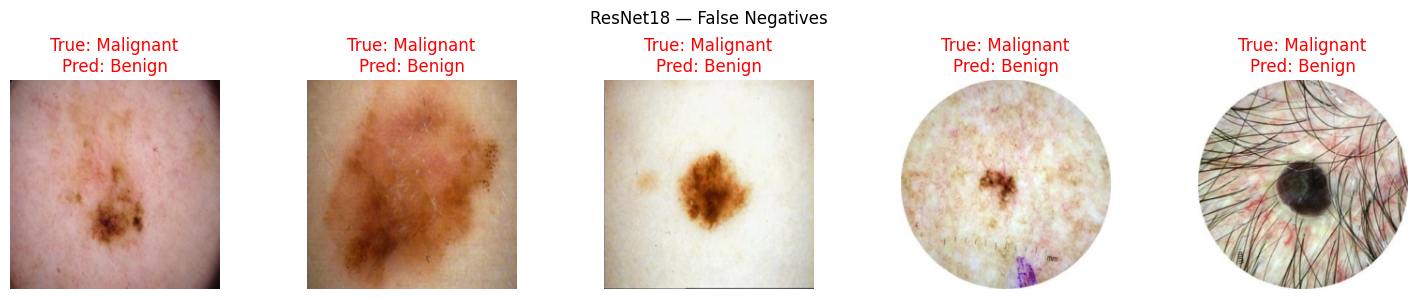

ResNet18: 24 false positives found


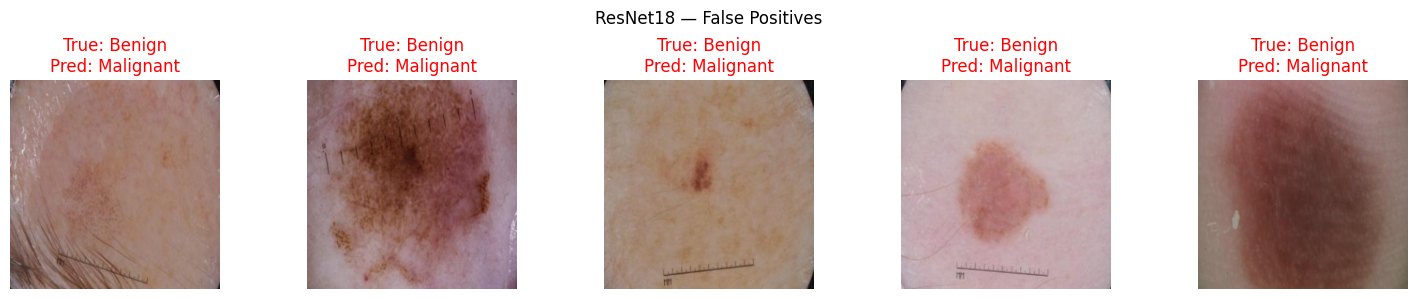

EfficientNet → Test Accuracy: 90.40% | Correct: 904 | Incorrect: 96


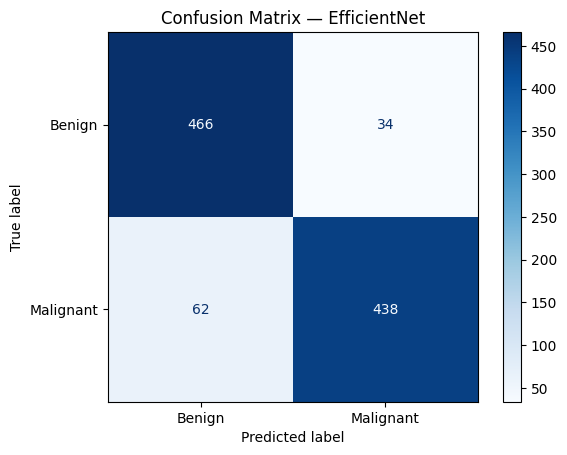

EfficientNet: 62 false negatives found


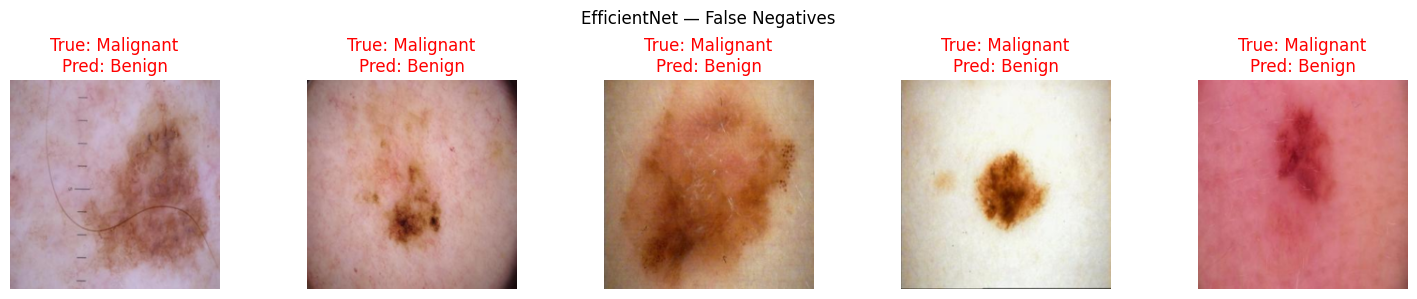

EfficientNet: 34 false positives found


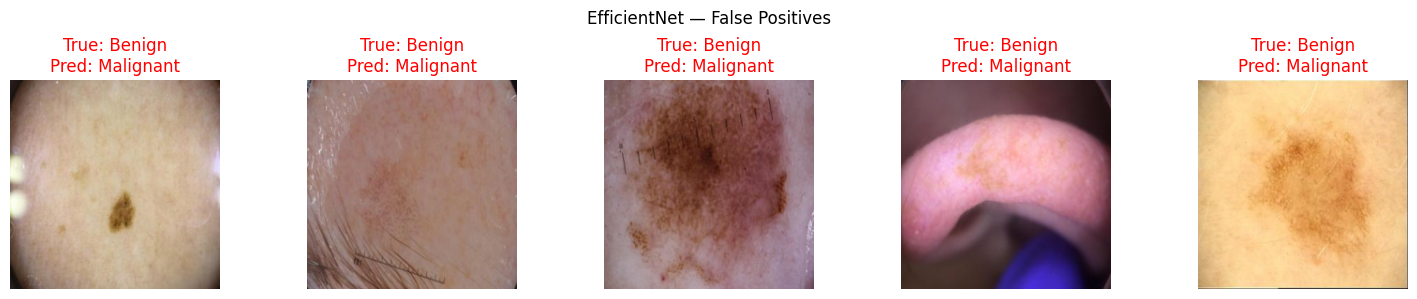

ViT → Test Accuracy: 90.80% | Correct: 908 | Incorrect: 92


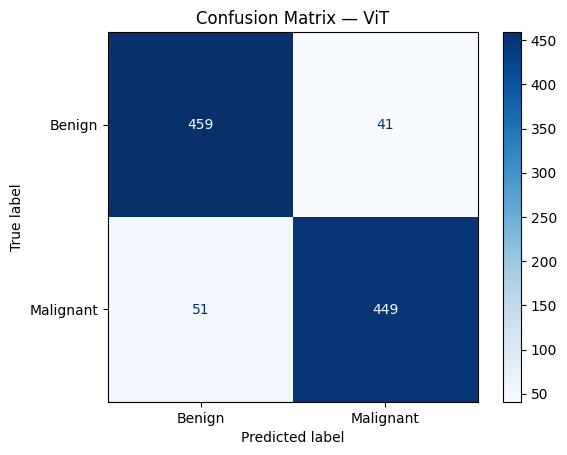

ViT: 51 false negatives found


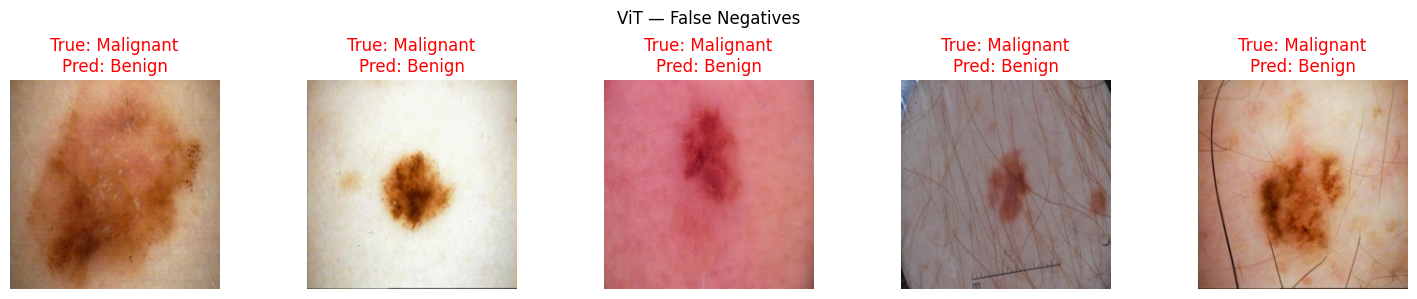

ViT: 41 false positives found


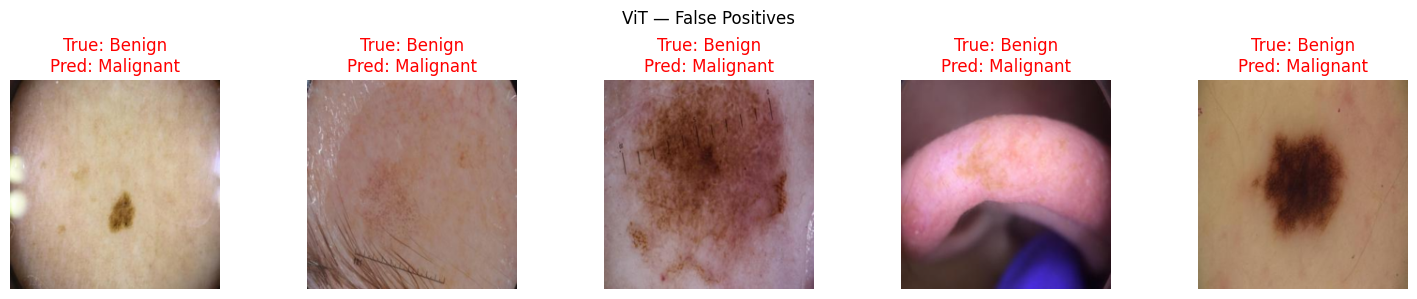

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader, device):
    """Helper function for running models on test data.

    Uses
    ----------
    test_loader
    Tracks correct and incorrect predictions

    Returns
    -------
    accuracy, correct_samples, incorrect_samples, all_images,
    all_preds, all_labels
    """
    model.eval()
    correct_samples = []
    incorrect_samples = []
    all_images = []
    all_preds = []
    all_labels = []

    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_images.extend(images.cpu())
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            for i in range(len(predicted)):
                if predicted[i] != labels[i]:
                    incorrect_samples.append((images[i].cpu(), predicted[i].cpu(), labels[i].cpu()))
                else:
                    correct_samples.append((images[i].cpu(), predicted[i].cpu(), labels[i].cpu()))

    accuracy = 100 * correct / total
    return accuracy, correct_samples, incorrect_samples, all_images, all_preds, all_labels


def plot_confusion_matrix(all_preds, all_labels, model_name):
    """Plots confusion matrix

    Uses
    ----------
    all_preds, all_labels, model

    Returns
    -------
    Plot of confusion matrix with appropriate labels.
    """
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()


def show_fn_examples(all_images, all_preds, all_labels, model_name, n=5):
    """Displays 5 examples of the false negative class

    Uses
    ----------
    all_images, all_preds, all_labels, model_name

    Returns
    -------
    Examples of test images that were incorrectly classified as benign
    """
    fn_images = [
        img for img, pred, label in zip(all_images, all_preds, all_labels)
        if label == 1 and pred == 0
    ]
    print(f"{model_name}: {len(fn_images)} false negatives found")

    fig, axes = plt.subplots(1, min(n, len(fn_images)), figsize=(15, 3))
    for ax, img in zip(axes, fn_images[:n]):
        img = img * 0.5 + 0.5
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
        ax.set_title("True: Malignant\nPred: Benign", color="red")
        ax.axis("off")
    plt.suptitle(f"{model_name} — False Negatives")
    plt.tight_layout()
    plt.show()

def show_fp_examples(all_images, all_preds, all_labels, model_name, n=5):
    """Displays 5 examples of the false positive class

    Uses
    ----------
    all_images, all_preds, all_labels, model_name

    Returns
    -------
    Examples of test images that were incorrectly classified as malignant.
    """
    fn_images = [
        img for img, pred, label in zip(all_images, all_preds, all_labels)
        if label == 0 and pred == 1
    ]
    print(f"{model_name}: {len(fn_images)} false positives found")

    fig, axes = plt.subplots(1, min(n, len(fn_images)), figsize=(15, 3))
    for ax, img in zip(axes, fn_images[:n]):
        img = img * 0.5 + 0.5
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
        ax.set_title("True: Benign\nPred: Malignant", color="red")
        ax.axis("off")
    plt.suptitle(f"{model_name} — False Positives")
    plt.tight_layout()
    plt.show()



for name, m in [("CNN", cnn), ("ResNet18", res18), ("EfficientNet", efficientnet), ("ViT", vit)]:
    acc, correct_samples, incorrect_samples, all_images, all_preds, all_labels = evaluate_model(m, test_loader, device)
    print(f"{name} → Test Accuracy: {acc:.2f}% | Correct: {len(correct_samples)} | Incorrect: {len(incorrect_samples)}")
    plot_confusion_matrix(all_preds, all_labels, name)
    show_fn_examples(all_images, all_preds, all_labels, name)
    show_fp_examples(all_images, all_preds, all_labels, name)